<a href="https://colab.research.google.com/github/abdulmusai/dsn-mart-sales-prediction/blob/main/DSN_Bootcamp_Qualification_Hackathon_2026_ML_Track%00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import KFold
import lightgbm as lgb
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_SPLITS = 5

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['How to get started with Drive.pdf',
 'FAQs ON THE DEVELOPMENT BANK OF NIGERIA FUND (1).pdf',
 'How can I apply for DBN Loan.pdf',
 'FAQs ON THE DEVELOPMENT BANK OF NIGERIA FUND.pdf',
 'IMG_20200317_100405.jpg',
 'Copy of Best 15 - A.I News.pdf',
 'Copy of Code3.rar',
 'Copy of 11 A.I INTERVIEW QUESTIONS.pdf',
 'New Doc 2021-10-31_2.jpg',
 'New Doc 2021-10-31_3.jpg',
 'New Doc 2021-10-31_1.jpg',
 'Nura 1.pdf',
 'Screenshot_20220918-115136 (1).jpg',
 'Screenshot_20220918-115136.jpg',
 'Expression of Interest.doc',
 'MY CURRICULUM_VATAE[1].doc',
 'NTI.pdf',
 'NGO CV (1).doc',
 'NGO CV.doc',
 'Copy of SPSS Demystified.  A Step-by-Step Guide to Successful Data Analysis ( PDFDrive ).pdf',
 'my links.docx',
 'Simplilearn Certificate.pdf',
 'inbound3027307747384480144.jpg',
 'Abdulrahman Cert.pdf',
 'file-JA55gHhdcZ88Sp6JTgrbqt.webp',
 '1744400323396.png',
 'file_0000000089286230b7865a460aa44952_conversation_id=67faae86-d418-800b-a675-3e8c0e0cec22&message_id=57100371-dfd4-4faa-875c-315e98c05

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/DSN_Hackathon_2026_Data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/DSN_Hackathon_2026_Data/test.csv')

train['is_train'] = 1
test['is_train'] = 0
test['total_sales'] = np.nan
full = pd.concat([train, test], axis=0, ignore_index=True)

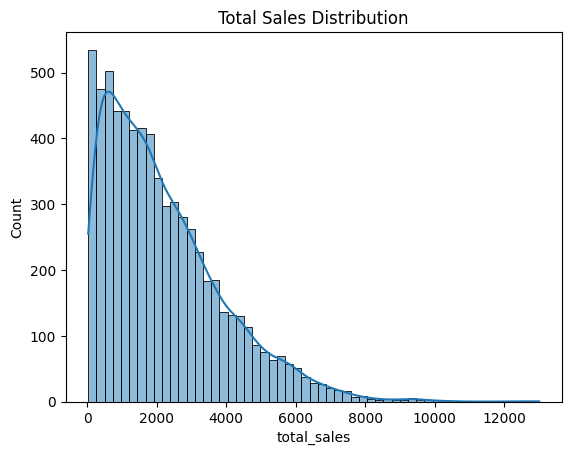

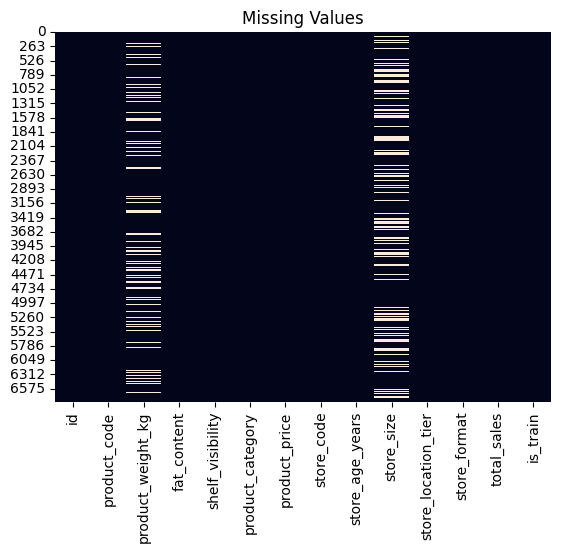

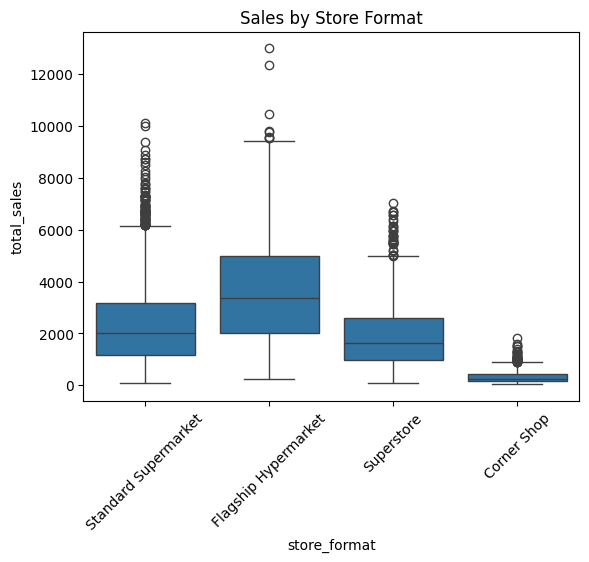

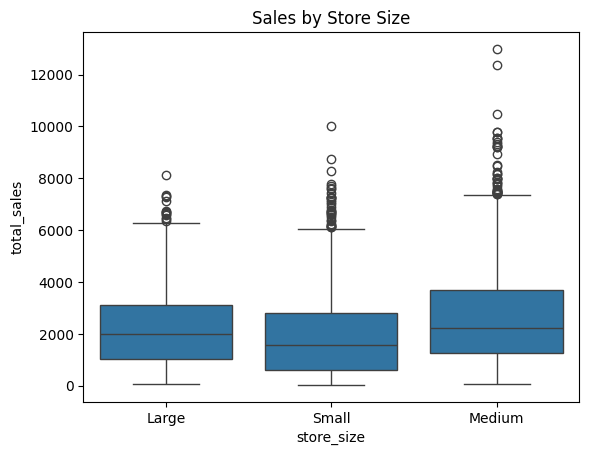

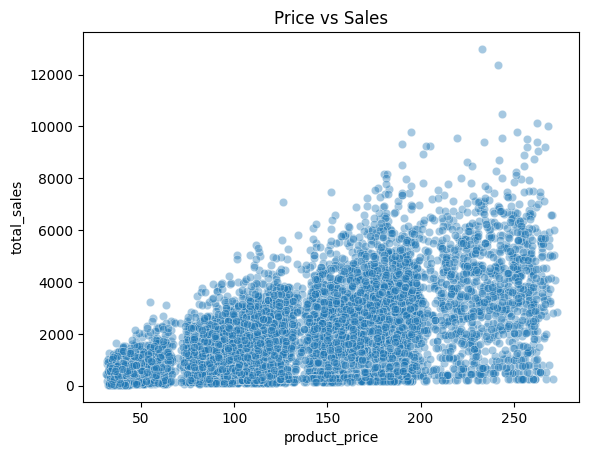

Rows with shelf_visibility == 0: 422


In [ ]:

# Target distribution
sns.histplot(train['total_sales'], kde=True)
plt.title('Total Sales Distribution')
plt.show()

# Missing values
sns.heatmap(train.isnull(), cbar=False)
plt.title('Missing Values')
plt.show()

# Sales by store format / size
sns.boxplot(data=train, x='store_format', y='total_sales')
plt.xticks(rotation=45)
plt.title('Sales by Store Format')
plt.show()

sns.boxplot(data=train, x='store_size', y='total_sales')
plt.title('Sales by Store Size')
plt.show()

# Price vs sales
sns.scatterplot(data=train, x='product_price', y='total_sales', alpha=0.4)
plt.title('Price vs Sales')
plt.show()

# shelf_visibility == 0 check (this is what tells you to treat it as missing)
print('Rows with shelf_visibility == 0:', (train['shelf_visibility'] == 0).sum())

In [ ]:

# ---------- 1. Clean product_category casing ----------
full['product_category'] = full['product_category'].str.strip().str.title()
full['product_category'] = full['product_category'].replace({
    'Fruits And Vegetables': 'Fruits and Vegetables',
    'Health And Hygiene': 'Health and Hygiene',
})
perishable = {'Dairy', 'Meat', 'Seafood', 'Fruits and Vegetables', 'Breads', 'Breakfast'}
full['category_group'] = np.where(full['product_category'].isin(perishable), 'Perishable', 'Non-Perishable')

In [ ]:

# ---------- 2. Impute product_weight_kg ----------
weight_by_code = full.groupby('product_code')['product_weight_kg'].transform('mean')
full['product_weight_kg'] = full['product_weight_kg'].fillna(weight_by_code)
cat_mean_weight = full.groupby('product_category')['product_weight_kg'].transform('mean')
full['product_weight_kg'] = full['product_weight_kg'].fillna(cat_mean_weight)

In [ ]:

# ---------- 3. Fix shelf_visibility == 0 ----------
full.loc[full['shelf_visibility'] == 0, 'shelf_visibility'] = np.nan
vis_by_cat = full.groupby('product_category')['shelf_visibility'].transform('mean')
full['shelf_visibility'] = full['shelf_visibility'].fillna(vis_by_cat)

In [ ]:

# ---------- 4. store_size missingness ----------
full['store_size'] = full['store_size'].fillna('Missing')

In [ ]:

# ---------- 5. Basic feature engineering ----------
full['store_age_bucket'] = pd.cut(full['store_age_years'], bins=[0, 10, 20, 30, 40, 100],
                                   labels=['0-10', '11-20', '21-30', '31-40', '40+'])
full['price_per_kg'] = full['product_price'] / full['product_weight_kg']
full['price_rank_in_category'] = full.groupby('product_category')['product_price'].rank(pct=True)
full['product_count_in_store'] = full.groupby('store_code')['product_code'].transform('count')
full['store_count_for_product'] = full.groupby('product_code')['store_code'].transform('count')

train_fe = full[full['is_train'] == 1].copy().reset_index(drop=True)
test_fe = full[full['is_train'] == 0].copy().reset_index(drop=True)

y_log = np.log1p(train_fe['total_sales'])

In [ ]:

# ---------- 6. Out-of-fold smoothed target encoding (leak-free) ----------
def smoothed_te_oof(train_df, test_df, col, target, n_splits=5, smoothing=10, seed=42):
    global_mean = target.mean()
    oof = np.full(len(train_df), np.nan)
    kf_te = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf_te.split(train_df):
        stats = target.iloc[tr_idx].groupby(train_df[col].iloc[tr_idx]).agg(['mean', 'count'])
        smooth = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        oof[val_idx] = train_df[col].iloc[val_idx].map(smooth).fillna(global_mean).values
    # full-train stats for encoding test set
    stats_full = target.groupby(train_df[col]).agg(['mean', 'count'])
    smooth_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
    test_enc = test_df[col].map(smooth_full).fillna(global_mean).values
    return oof, test_enc

for col in ['product_code', 'store_code', 'product_category']:
    oof_enc, test_enc = smoothed_te_oof(train_fe, test_fe, col, y_log, n_splits=5, smoothing=10)
    train_fe[f'{col}_te'] = oof_enc
    test_fe[f'{col}_te'] = test_enc



cat_cols = ['fat_content', 'product_category', 'category_group',
            'store_code', 'store_size', 'store_location_tier', 'store_format', 'store_age_bucket']
for c in cat_cols:
    train_fe[c] = train_fe[c].astype('category')
    test_fe[c] = test_fe[c].astype('category')

feature_cols = ['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category',
                 'category_group', 'product_price', 'store_code', 'store_age_years', 'store_size',
                 'store_location_tier', 'store_format', 'store_age_bucket', 'price_per_kg',
                 'product_count_in_store', 'store_count_for_product',
                 'product_code_te', 'store_code_te', 'product_category_te']

X = train_fe[feature_cols]
y = y_log
X_test = test_fe[feature_cols]

cat_feature_names = [c for c in cat_cols if c in feature_cols]
cat_idx = [X.columns.get_loc(c) for c in cat_feature_names]

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_xgb = np.zeros(len(X))          # put these two lines near your other oof_/test_pred_ inits
test_pred_xgb = np.zeros(len(X_test))
test_pred_lgb = np.zeros(len(X_test))
test_pred_cat = np.zeros(len(X_test))

lgb_params = dict(
    objective='regression', metric='rmse', n_estimators=3000, learning_rate=0.02,
    num_leaves=31, min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=RANDOM_STATE, verbosity=-1,
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # LightGBM
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_lgb[val_idx] = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration_)
    test_pred_lgb += lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration_) / N_SPLITS

    # CatBoost
    cat_model = CatBoostRegressor(
        iterations=3000, learning_rate=0.03, depth=6, loss_function='RMSE',
        random_seed=RANDOM_STATE, verbose=False, early_stopping_rounds=100,
        cat_features=cat_idx,
    )
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
    oof_cat[val_idx] = cat_model.predict(X_val)
    test_pred_cat += cat_model.predict(X_test) / N_SPLITS

    # XGBoost
    xgb_model = xgb.XGBRegressor(
        n_estimators=3000, learning_rate=0.02, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        random_state=RANDOM_STATE, enable_categorical=True, early_stopping_rounds=100
    )
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_model.predict(X_val)
    test_pred_xgb += xgb_model.predict(X_test) / N_SPLITS


y_orig = train_fe['total_sales'].values

def rmse_orig(oof_log):
    return np.sqrt(np.mean((np.expm1(oof_log) - y_orig) ** 2))

print(f'LightGBM CV RMSE: {rmse_orig(oof_lgb):.4f}')
print (f'CatBoost CV RMSE: {rmse_orig(oof_cat):.4f}')
print(f'XGBoost CV RMSE: {rmse_orig(oof_xgb):.4f}')

LightGBM CV RMSE: 1121.1846
CatBoost CV RMSE: 1109.8153
XGBoost CV RMSE: 1128.2454


In [ ]:

best_score, best_weights = np.inf, None
for w1 in np.arange(0, 1.05, 0.1):
    for w2 in np.arange(0, 1.05 - w1, 0.1):
        w3 = 1 - w1 - w2
        blend = w1*oof_lgb + w2*oof_cat + w3*oof_xgb
        r = rmse_orig(blend)
        if r < best_score:
            best_score, best_weights = r, (w1, w2, w3)

print(f'Best weights (LGB, Cat, XGB) = {best_weights}, RMSE = {best_score:.4f}')

w1, w2, w3 = best_weights
final_test_log = w1*test_pred_lgb + w2*test_pred_cat + w3*test_pred_xgb
final_test = np.clip(np.expm1(final_test_log), 0, None)


submission = pd.DataFrame({'id': test_fe['id'].values, 'total_sales': final_test})
submission.to_csv('submission.csv', index=False)
print(submission.head())

Best weights (LGB, Cat, XGB) = (np.float64(0.0), np.float64(1.0), np.float64(0.0)), RMSE = 1109.8153
          id  total_sales
0  row_00009  2407.700231
1  row_00015  3629.092307
2  row_00019  2805.333719
3  row_00020  2940.787852
4  row_00023  2314.892563


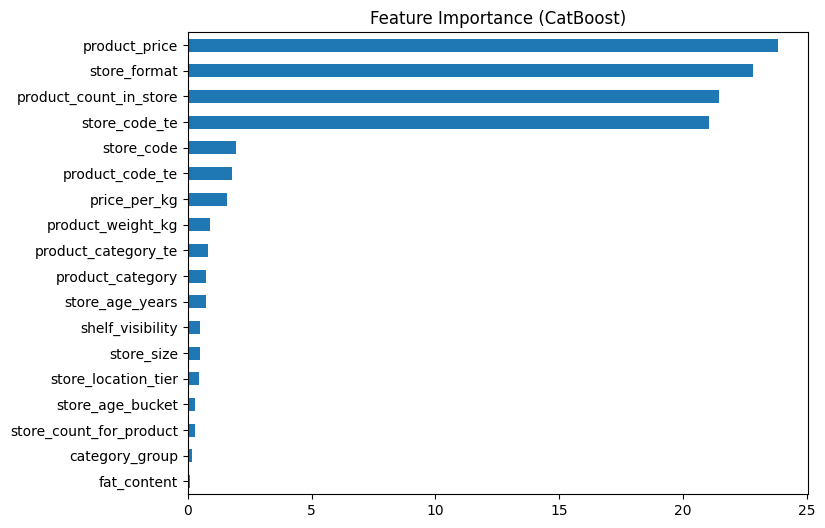

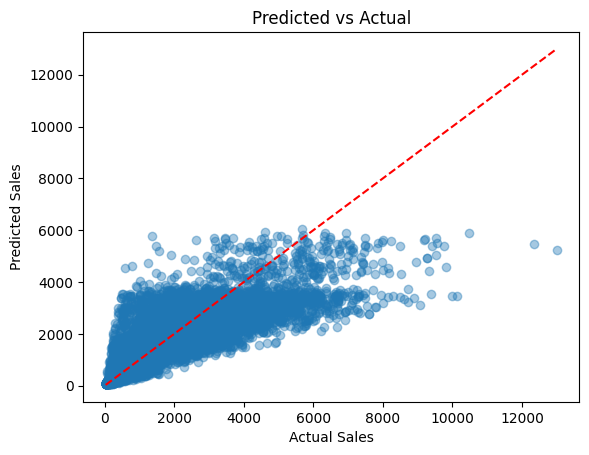

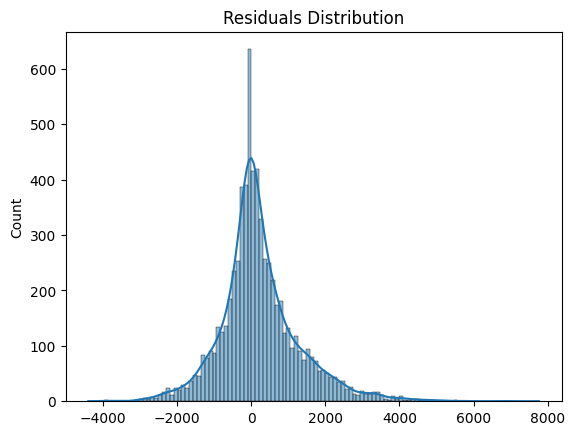

In [ ]:

# Feature importance
imp = pd.Series(cat_model.feature_importances_, index=feature_cols).sort_values()
imp.plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance (CatBoost)')
plt.show()

# Predicted vs actual (on OOF predictions)
plt.scatter(y_orig, np.expm1(oof_cat), alpha=0.4)
plt.plot([y_orig.min(), y_orig.max()], [y_orig.min(), y_orig.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual')
plt.show()

# Residuals
residuals = y_orig - np.expm1(oof_cat)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.show()

In [ ]:
submission.to_csv('/submission.csv', index=False)

from google.colab import files
files.download('/submission.csv')

print('Saved improved submission.csv with', len(submission), 'rows')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved improved submission.csv with 1705 rows
